In [5]:
import pandas as pd

train_data = pd.read_csv('train.csv')
train_data.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_data = pd.read_csv('test.csv')
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
summary = train_data.describe()
summary

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train_data.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
train_data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
missing = train_data.isnull().sum()
print("Missing values :",missing)

Missing values : PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


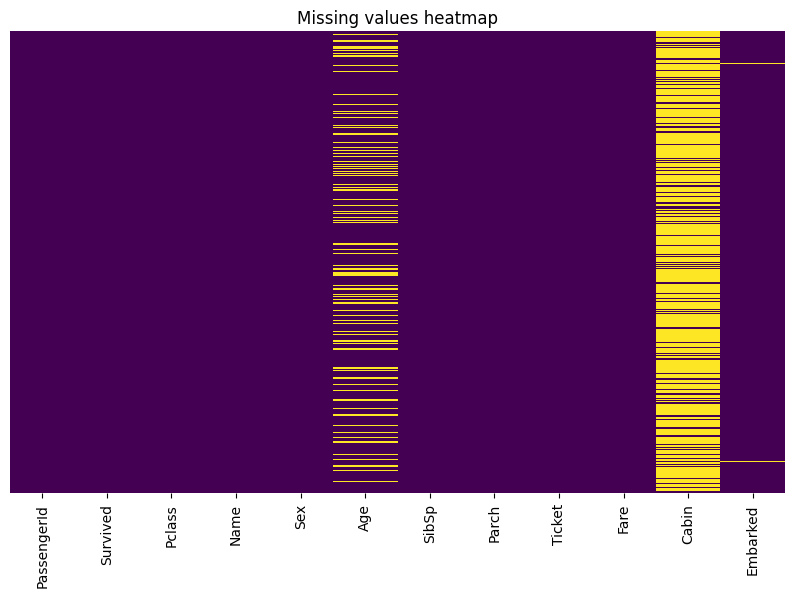

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(train_data.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Missing values heatmap')
plt.show()

In [13]:
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
train_data.drop('Cabin',axis=1,inplace=True)


/tmp/ipykernel_1915/3339034563.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace=True)


In [14]:
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'].fillna(most_common_embarked, inplace=True)

/tmp/ipykernel_1915/3508393822.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Embarked'].fillna(most_common_embarked, inplace=True)


In [15]:
missing_values_after_handling = train_data.isnull().sum()
print("Missing values after handling:",missing_values_after_handling)

Missing values after handling: PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
survival_percentage = (train_data['Survived'].sum() / len(train_data))*100
print("The percentage of people who survived: ",survival_percentage)

The percentage of people who survived:  38.38383838383838


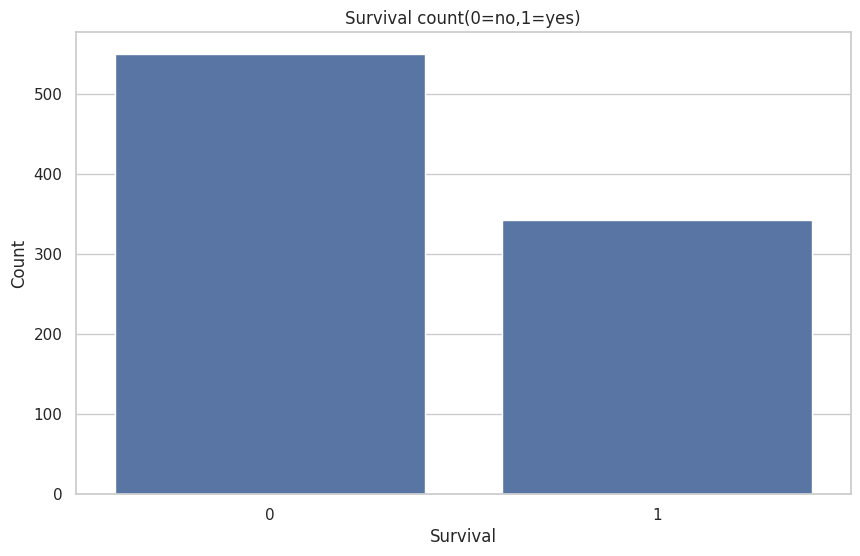

In [17]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.countplot(x='Survived', data=train_data)
plt.title('Survival count(0=no,1=yes)')
plt.xlabel('Survival')
plt.ylabel('Count')
plt.show()

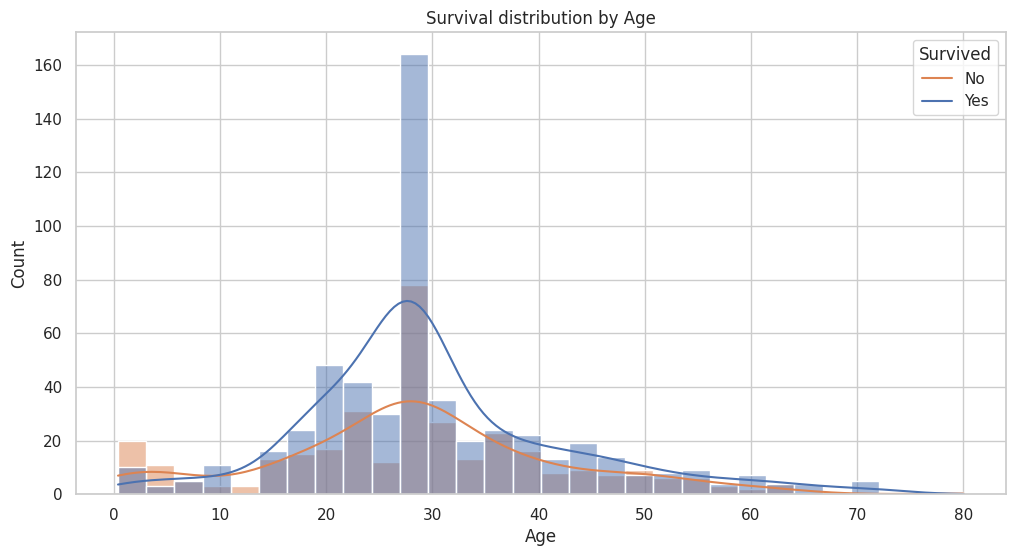

In [18]:
plt.figure(figsize=(12,6))
sns.histplot(x='Age',hue='Survived', data=train_data, kde=True)
plt.title('Survival distribution by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title = 'Survived',labels=['No',"Yes"])
plt.show()

/tmp/ipykernel_1915/369379520.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex',y='Survived',data=train_data,ci=None)


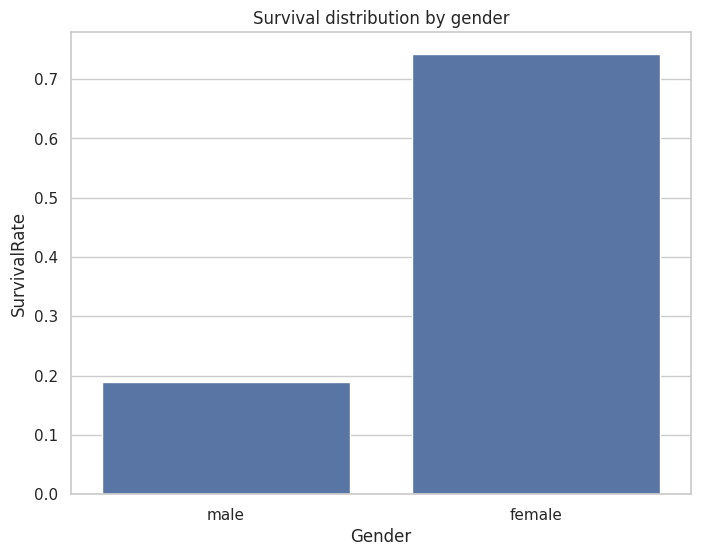

In [19]:
plt.figure(figsize=(8,6))
sns.barplot(x='Sex',y='Survived',data=train_data,ci=None)
plt.title('Survival distribution by gender')
plt.xlabel('Gender')
plt.ylabel('SurvivalRate')
plt.show()

In [20]:
train_data_copy = train_data.copy()

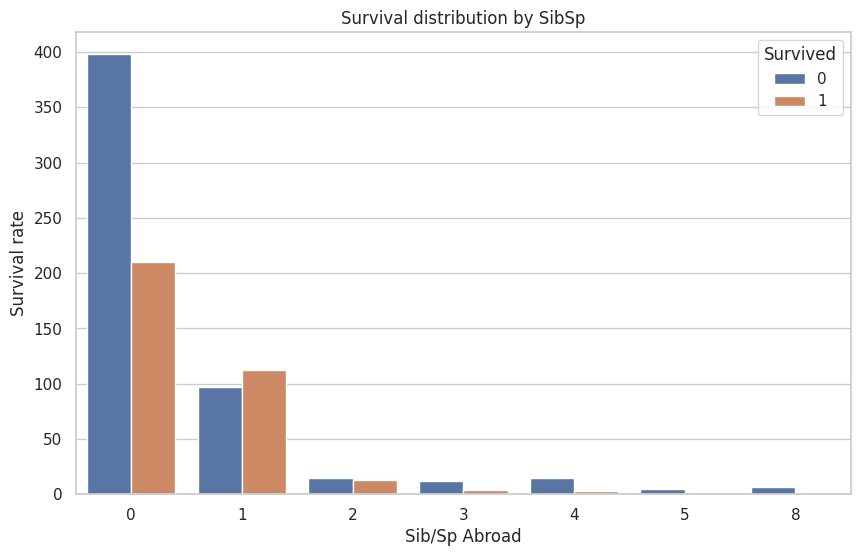

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(x='SibSp', hue='Survived',data=train_data_copy)
plt.title('Survival distribution by SibSp')
plt.xlabel('Sib/Sp Abroad')
plt.ylabel('Survival rate')
plt.show()

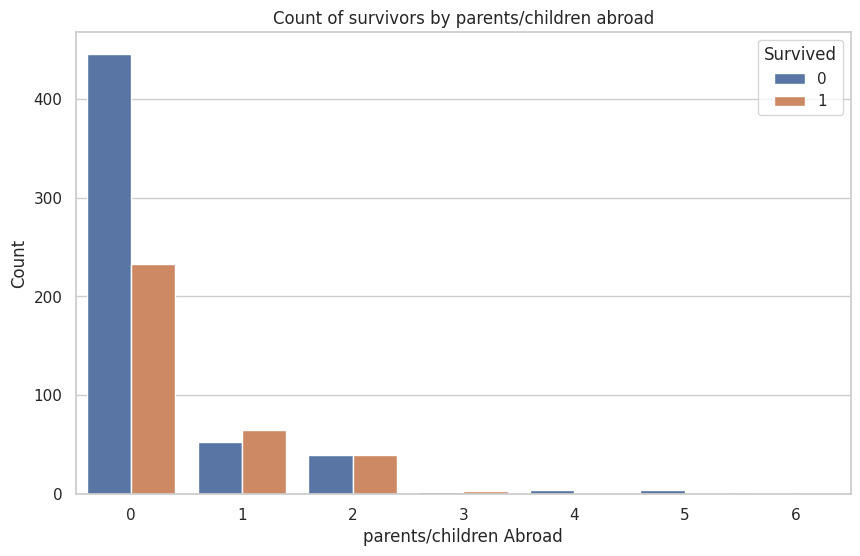

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(x='Parch', hue='Survived',data=train_data_copy)
plt.title('Count of survivors by parents/children abroad')
plt.xlabel('parents/children Abroad')
plt.ylabel('Count')
plt.show()

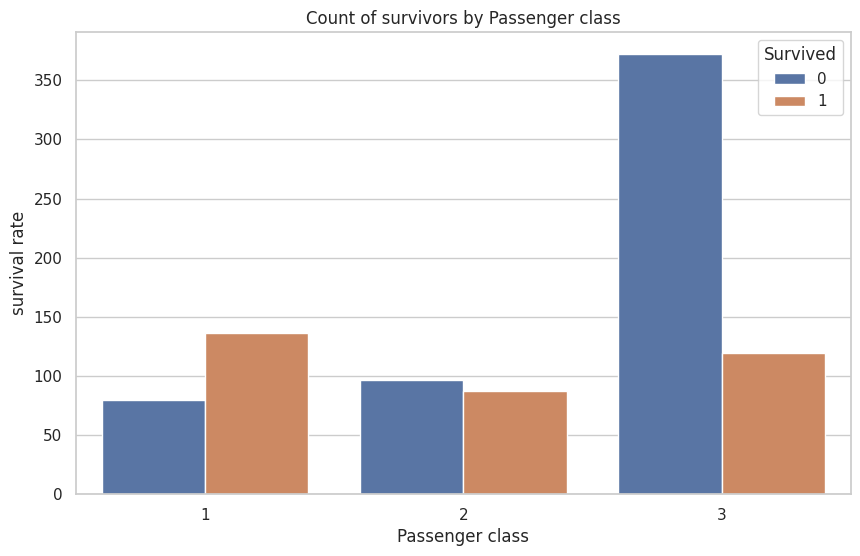

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(x='Pclass', hue='Survived',data=train_data_copy)
plt.title('Count of survivors by Passenger class')
plt.xlabel('Passenger class')
plt.ylabel('survival rate')
plt.show()

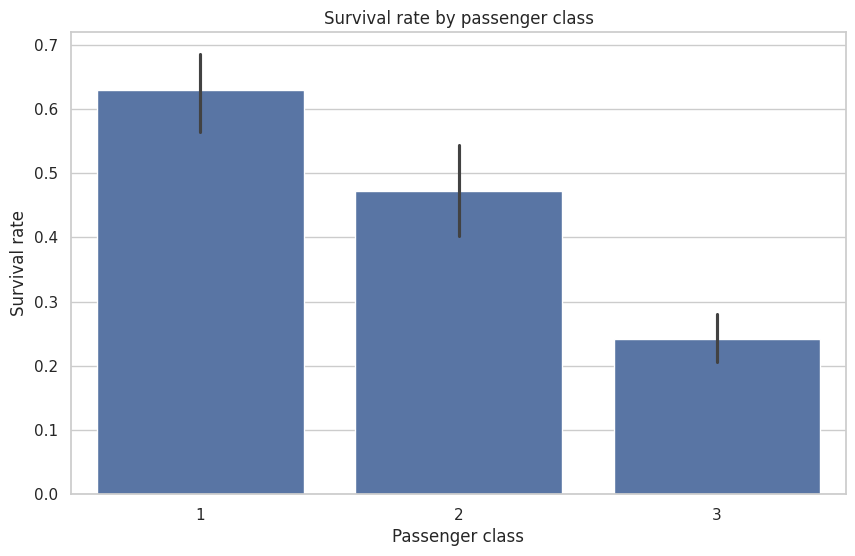

In [24]:
train_data['Survived'] = train_data['Survived'].astype(int)
plt.figure(figsize=(10,6))
sns.barplot(x='Pclass',y='Survived',data=train_data)
plt.title('Survival rate by passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Survival rate')
plt.show()

In [25]:
average_fare = train_data.groupby('Survived')['Fare'].mean()
print("Average fare for non-survived passengers:",average_fare[0])
print("Average fare for survived passengers:",average_fare[1])

Average fare for non-survived passengers: 22.117886885245902
Average fare for survived passengers: 48.39540760233918


In [26]:
embarked_survival = pd.crosstab(train_data['Embarked'],train_data['Survived'],margins = True,margins_name='Total')
print(embarked_survival)

Survived    0    1  Total
Embarked                 
C          75   93    168
Q          47   30     77
S         427  219    646
Total     549  342    891


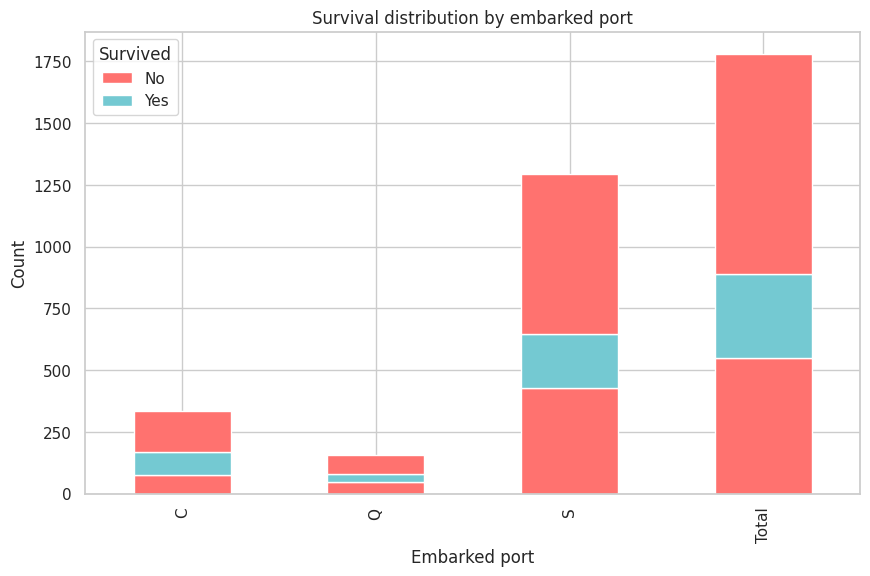

In [27]:
embarked_survival.plot(kind='bar',stacked=True,color=['#FF726F','#74C9D2'],figsize=(10,6))
plt.title('Survival distribution by embarked port')
plt.xlabel('Embarked port')
plt.ylabel('Count')
plt.legend(title='Survived',labels=['No','Yes'])
plt.show()

In [28]:
embarked_survival_rate = pd.crosstab(index=train_data['Embarked'],columns=train_data['Survived'],normalize='index')*100
print(embarked_survival_rate)

Survived          0          1
Embarked                      
C         44.642857  55.357143
Q         61.038961  38.961039
S         66.099071  33.900929


In [29]:
test_data=pd.read_csv('test.csv')
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [30]:
train_data = train_data.drop(['Name'],axis=1)

In [31]:
train_data = train_data.drop(['PassengerId','Ticket'],axis=1)

In [32]:
train_data = pd.get_dummies(train_data, columns=['Pclass','Sex','Embarked'],drop_first=True)

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_cols = ['Age','SibSp','Parch','Fare']
train_data[numerical_cols] = scaler.fit_transform(train_data[numerical_cols])

In [34]:
X = train_data.drop('Survived',axis=1)
Y = train_data['Survived']

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [37]:
param_grid = {
  'RandomForest' :{
    'n_estimators' :[50,100,150],
    'max_depth' : [None,10,20,30],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]
},
  'GradientBoosting' :{
      'n_estimators' : [50,100,150],
      'learning_rate' : [0.01,0.1,0.2],
      'max_depth' : [3,4,7],
      'min_samples_split': [2,5,10],
      'min_samples_leaf' : [1,2,4]
  },
  'SVC' :{
      'C' : [0.1,1,10],
      'gamma':[0.01,0.1,1],
      'kernel' : ['linear','rbf'],

  },
}


In [38]:
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svc = SVC()

In [39]:
grid_rf = GridSearchCV(rf,param_grid['RandomForest'],cv=5)
grid_rf.fit(X_train,Y_train)

grid_gb = GridSearchCV(gb,param_grid['GradientBoosting'],cv=5)
grid_gb.fit(X_train,Y_train)

grid_svc = GridSearchCV(svc,param_grid['SVC'],cv=5)
grid_svc.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf']})

In [40]:
print("Random forest-best parameters: ",grid_rf.best_params_)
print("Random forest-best score: ",grid_rf.best_score_)

print("Gradient boosting-best parameters: ",grid_gb.best_params_)
print("Gradient boosting-best score: ",grid_gb.best_score_)

print("SVC-best parameters: ",grid_svc.best_params_)
print("SVC-best score: ",grid_svc.best_score_)

Random forest-best parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Random forest-best score:  0.8314488328572835
Gradient boosting-best parameters:  {'learning_rate': 0.01, 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Gradient boosting-best score:  0.8272530286614794
SVC-best parameters:  {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
SVC-best score:  0.8174135723431497


In [41]:
best_rf_model = RandomForestClassifier(
    n_estimators = 150,
    max_depth = None,
    min_samples_split = 5,
    min_samples_leaf = 2,
    random_state = 42

)

In [42]:
best_rf_model.fit(X_train,Y_train)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                       n_estimators=150, random_state=42)

In [43]:
y_pred = best_rf_model.predict(X_test)


In [46]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score( Y_test ,y_pred)
print("Accuracy: ",accuracy)

Accuracy:  0.8435754189944135


In [47]:
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)
test_data.drop('Cabin',axis=1,inplace=True)

/tmp/ipykernel_1915/963165354.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
/tmp/ipykernel_1915/963165354.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [48]:
most_common_embarked_test = test_data['Embarked'].mode()[0]
test_data['Embarked'].fillna(most_common_embarked_test,inplace = True)
test_data = test_data.drop(['Name','PassengerId','Ticket'],axis = 1)
test_data = pd.get_dummies(test_data,columns=['Pclass','Sex','Embarked'],drop_first=True)
test_data[numerical_cols] = scaler.transform(test_data[numerical_cols])

/tmp/ipykernel_1915/3316198136.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Embarked'].fillna(most_common_embarked_test,inplace = True)


In [49]:
new_prediction = best_rf_model.predict(test_data)

In [50]:
test_data['Survived_prediction'] = new_prediction
test_data

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived_prediction
0,0.428248,0.000,0.000000,0.015282,False,True,True,True,False,0
1,0.585323,0.125,0.000000,0.013663,False,True,False,False,True,0
2,0.773813,0.000,0.000000,0.018909,True,False,True,True,False,0
3,0.334004,0.000,0.000000,0.016908,False,True,True,False,True,0
4,0.271174,0.125,0.166667,0.023984,False,True,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...
413,0.334004,0.000,0.000000,0.015713,False,True,True,False,True,0
414,0.484795,0.000,0.000000,0.212559,False,False,False,False,False,1
415,0.478512,0.000,0.000000,0.014151,False,True,True,False,True,0
416,0.334004,0.000,0.000000,0.015713,False,True,True,False,True,0


In [53]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy*100)

Accuracy: 84.35754189944134
